In [61]:
from qiskit import QuantumCircuit
from qiskit_aer.primitives import Estimator
import matplotlib.pyplot as plt 
import numpy as np 
from qiskit.quantum_info import Statevector, random_clifford 
import os

In [62]:
from tomography import SelfGuidedTomography, Mean_Direct_Fidelity

In [63]:
NQ = 2
MDF = Mean_Direct_Fidelity(NQ)
state = np.random.randn( 2**NQ )
state = state / np.linalg.norm( state )

In [64]:
Omega = random_clifford( NQ ).to_circuit()
state = np.array( Statevector(Omega) )
state

array([ 0.35355339-0.35355339j,  0.35355339+0.35355339j,
       -0.35355339+0.35355339j, -0.35355339-0.35355339j])

In [65]:
MDF.Chi( state, None ).round(2)

array([ 0.5+0.j, -0. +0.j,  0.5+0.j,  0. -0.j, -0.5+0.j,  0. +0.j,
       -0.5+0.j,  0. +0.j,  0. +0.j,  0. +0.j,  0. +0.j,  0. +0.j,
        0. +0.j,  0. +0.j,  0. +0.j,  0. +0.j])

In [66]:
alpha = 0 #1 / 2**NQ
MDF.Chi( state, truncation=alpha ).round(2)

array([ 0.5+0.j, -0. +0.j,  0.5+0.j,  0. -0.j, -0.5+0.j,  0. +0.j,
       -0.5+0.j,  0. +0.j,  0. +0.j,  0. +0.j,  0. +0.j,  0. +0.j,
        0. +0.j,  0. +0.j,  0. +0.j,  0. +0.j])

In [67]:
np.outer( state, state.conj() ).round(2)

array([[ 0.25-0.j  , -0.  -0.25j, -0.25+0.j  ,  0.  +0.25j],
       [-0.  +0.25j,  0.25+0.j  ,  0.  -0.25j, -0.25-0.j  ],
       [-0.25+0.j  ,  0.  +0.25j,  0.25-0.j  , -0.  -0.25j],
       [ 0.  -0.25j, -0.25-0.j  , -0.  +0.25j,  0.25+0.j  ]])

### Initial Parameters

In [76]:
NQs = [2,3,4]
L = len(NQs)
N = 10
Niter = 1000
shots = 1000
simulator_ideal=Estimator(backend_options={'shots':shots,
                                            'method':"stabilizer",},
                            transpile_options={'optimization_level':0},
                            ) 

In [77]:
from joblib import Parallel, delayed

def simulate( NQ, simulator ):

    d = 2**NQ

    Omega = random_clifford( NQ ).to_circuit()
    OmegaM=np.outer(np.array(Statevector(Omega)),
                    (np.array(Statevector(Omega))).conj()) 

    psi0 = np.random.rand(d) + 1j * np.random.rand(d)
    psi0 = psi0 / np.linalg.norm(psi0)
    guess = psi0

    MDF = Mean_Direct_Fidelity(NQ)

    # stop_measuring = lambda x : ( np.linalg.norm( list( x.values() ) ) > 0.90 )
    stop_measuring = lambda x : ( len( list( x.values() ) ) > 2*2**NQ )

    I_ex = lambda x : 1 - MDF.MeanFidelity(1, 
                                            4*NQ**2, 
                                            x,
                                            Omega,
                                            simulator,
                                            truncation = None,
                                            stop_measuring = stop_measuring,  )
    
    I_th = lambda x: 1 - np.vdot( x, OmegaM@x )/(np.linalg.norm( x ))**2

    Fidelities = []
    Measures = []
    Last=[]
    norms = []
    def callback( i, x ):
        Last.append(x)
        Fidelities.append( I_th(x) )
        Measures.append(MDF.num_exp_meas)
        nnn = np.linalg.norm( list( MDF.Measures.values() ) )**2
        norms.append( nnn )
        return None

    SelfGuidedTomography( I_ex, 
                            guess, 
                            num_iter=1000, 
                            callback = callback,
                            )
    
    Results=[np.array(Fidelities), 
                np.array(Measures), 
                np.array(Last),
                np.array( norms )
                ] 

    return Results  #j index the average over the Hilbert space 


In [78]:
from joblib import Parallel, delayed

iterator = np.repeat(NQs, N).flatten()

R = Parallel(n_jobs=-1, verbose=11)(delayed(simulate)(int(NQ),simulator_ideal) for NQ in iterator)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:    9.6s
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    9.7s
[Parallel(n_jobs=-1)]: Done   3 tasks      | elapsed:    9.8s
[Parallel(n_jobs=-1)]: Done   4 tasks      | elapsed:    9.9s
[Parallel(n_jobs=-1)]: Done   5 tasks      | elapsed:   11.6s
[Parallel(n_jobs=-1)]: Done   6 tasks      | elapsed:   11.7s
[Parallel(n_jobs=-1)]: Done   7 tasks      | elapsed:   11.7s
[Parallel(n_jobs=-1)]: Done   8 tasks      | elapsed:   11.8s
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:   13.5s
[Parallel(n_jobs=-1)]: Done  10 tasks      | elapsed:   13.6s
[Parallel(n_jobs=-1)]: Done  11 tasks      | elapsed:   15.0s
[Parallel(n_jobs=-1)]: Done  12 tasks      | elapsed:   15.0s
[Parallel(n_jobs=-1)]: Done  13 tasks      | elapsed:   16.6s
[Parallel(n_jobs=-1)]: Done  14 tasks      | elapsed:   16.8s
[Parallel(n_jobs=-1)]: Done  15 tasks      | elapsed:   

In [84]:
Fids, Meas, _, Norm = [[[R[i + j * N][r] for i in range(N)] for j in range(len(NQs))]
                   for r in range(4)]

Fids = np.real(Fids)
Meas = np.array(Meas)
Norm = np.array(Norm) 

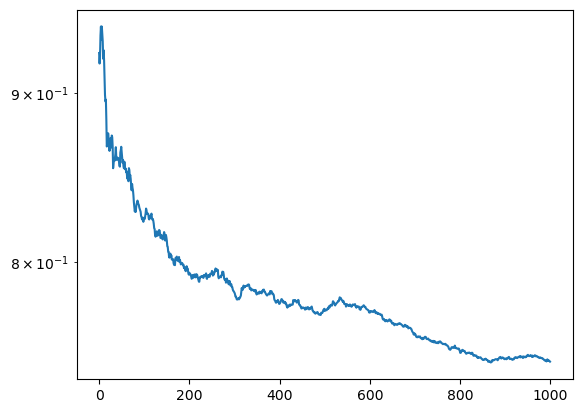

In [85]:
plt.semilogy( np.mean(Fids[-1], axis=0) )

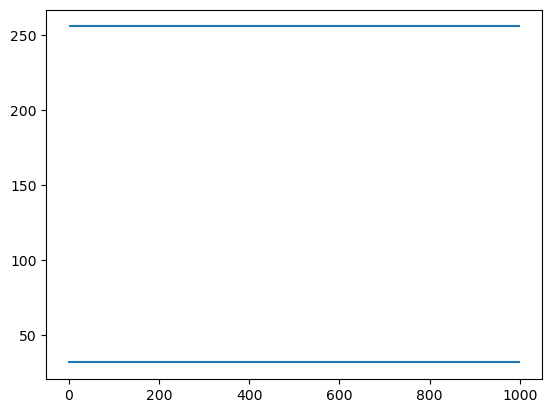

In [86]:
plt.plot( np.mean(Meas[-1], axis=0) )
plt.hlines(  4**4, 0, 1000  )

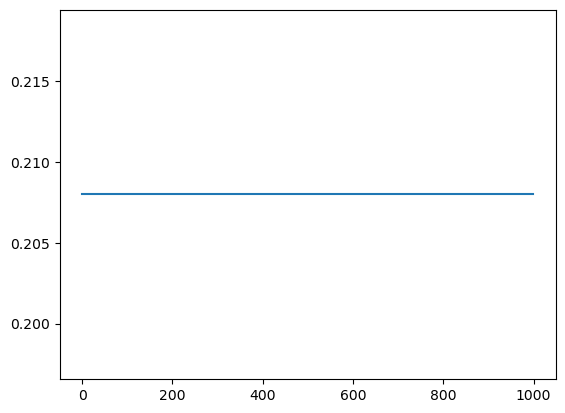

In [87]:
plt.plot( np.mean(Norm[-1], axis=0) )

In [88]:
# Save data. Ax order Fids and Meas are: [NQ, Nrun, Niter]

filename = "sgqt_without_truncation.npz"

data = {
    "N": [N],
    "shots": [shots],
    "Niter": [Niter],
    "NQs": NQs,
    "Fids": Fids,
    "Meas": Meas,
    "info": ["N, shots, and Niter are single integers in one array each.",
             "NQs is the array of number of qubits.",
             "Fids and Meas have shapes (len(NQs), N, Niter)"],
}

# Make directory "data" if not present
os.makedirs("data", exist_ok=True)

# Save
filepath = os.path.join("data", filename)
np.savez(filepath, **data)